# Add NKT cluster to reference dataset

In [1]:
%load_ext autoreload

In [2]:
import scanpy as sc
import numpy as np

In [3]:
adata = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/raw/"
    "public-anndata_project-232_1___published__87833b35-f160-46eb-a827-b7593c473084.AIDAv2DataFreezeCT.h5ad",
)

In [4]:
adata_raw = adata.raw.to_adata()
del adata.raw

In [5]:
adata

AnnData object with n_obs × n_vars = 1265624 × 36503
    obs: 'mapped_reference_assembly', 'mapped_reference_annotation', 'alignment_software', 'library_uuid', 'assay_ontology_term_id', 'library_starting_quantity', 'is_primary_data', 'cell_type--cell_ontology_term_id', 'author_cell_type', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage--cell_ontology_term_id', 'sample_derivation_process', 'donor_BMI_at_collection', 'tissue_type', 'suspension_derivation_process', 'suspension_enriched_cell_types', 'suspension_percent_cell_viability', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity--cell_ontology_term_id', 'donor_living_at_sample_collection', 'organism_ontology_term_id', 'disease_ontology_term_id', 'sex--cell_ontology_term_id', 'nCount_RNA', 'nFeature_RNA', 'pMito', 'NODG', 'nUMI', 'Country', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'author_cell_type--cell_ful

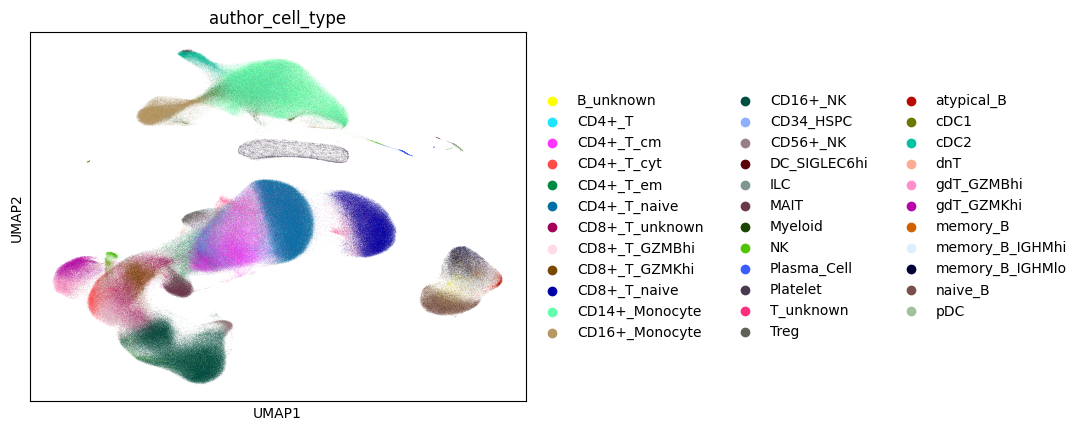

In [6]:
sc.pl.umap(adata, color=["author_cell_type"])

## Find NKT subcluster

In [7]:
NK_clusters = ["NK", "CD56+_NK", "CD16+_NK"]

In [8]:
adata_NK = adata[
    adata.obs["author_cell_type"].isin(NK_clusters)
]
adata_NK_raw = adata_raw[
    adata.obs["author_cell_type"].isin(NK_clusters)
]

In [9]:
adata_NK

View of AnnData object with n_obs × n_vars = 181041 × 36503
    obs: 'mapped_reference_assembly', 'mapped_reference_annotation', 'alignment_software', 'library_uuid', 'assay_ontology_term_id', 'library_starting_quantity', 'is_primary_data', 'cell_type--cell_ontology_term_id', 'author_cell_type', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage--cell_ontology_term_id', 'sample_derivation_process', 'donor_BMI_at_collection', 'tissue_type', 'suspension_derivation_process', 'suspension_enriched_cell_types', 'suspension_percent_cell_viability', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity--cell_ontology_term_id', 'donor_living_at_sample_collection', 'organism_ontology_term_id', 'disease_ontology_term_id', 'sex--cell_ontology_term_id', 'nCount_RNA', 'nFeature_RNA', 'pMito', 'NODG', 'nUMI', 'Country', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'author_cell_type--c

In [10]:
adata_NK.var.index = adata_NK.var["feature_name"].astype(str)
adata_NK_raw.var.index = adata_NK_raw.var["feature_names"].astype(str)

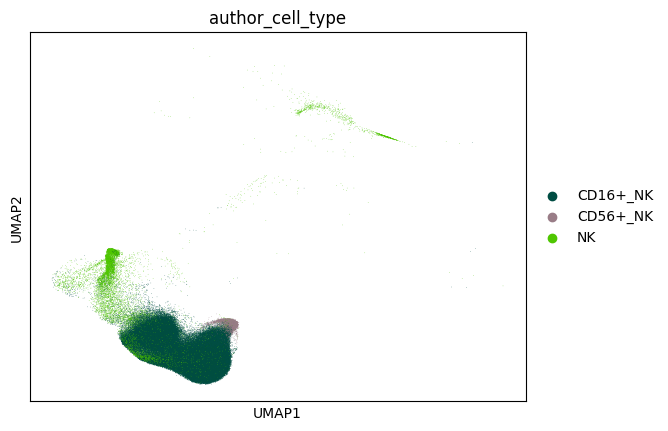

In [11]:
sc.pl.umap(adata_NK, color=["author_cell_type"])

In [12]:
# NKT markers: CD3E, CD4-, CD8A/CD8B-, FCGR3A, NKG7, GNLY, GZMB, PRF1, KLRC1
# Top DEGs from Query NKT cluster: ["GNLY", "FGFBP2", "NKG7", "GZMH", "GZMB", "PRF1", "CST7", "CCL5", "KLRD1"]

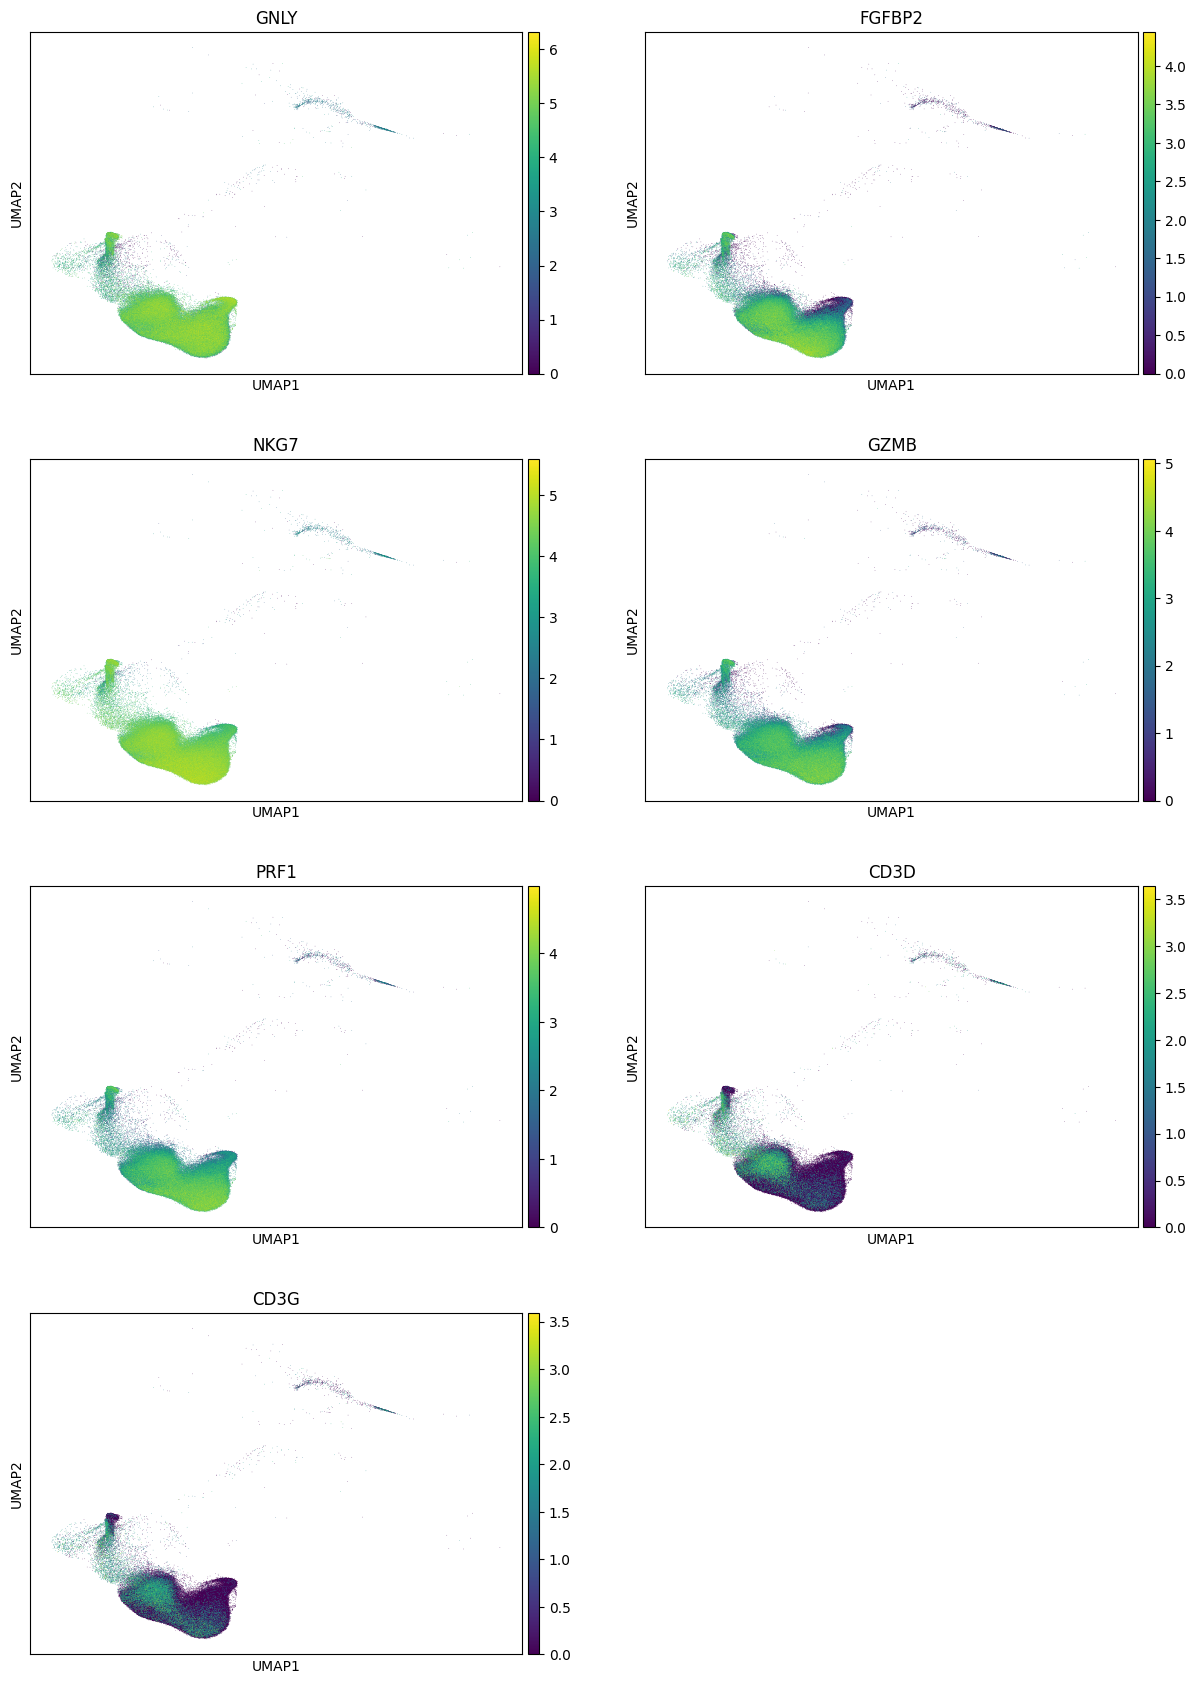

In [13]:
sc.pl.umap(
    adata_NK, 
    color=["GNLY", "FGFBP2", "NKG7", "GZMB", "PRF1", "CD3D", "CD3G"],
    ncols=2
)

In [14]:
sc.pp.pca(adata_NK)

In [15]:
sc.pp.neighbors(adata_NK)

In [16]:
sc.tl.leiden(adata_NK, resolution=0.25)

/tmp/ipykernel_145868/2305231664.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_NK, resolution=0.25)


In [17]:
adata_NK.obs.leiden.value_counts()

leiden
0    43152
1    39672
2    31926
3    28984
4    15511
5     8211
6     5771
7     4948
8     1812
9     1054
Name: count, dtype: int64

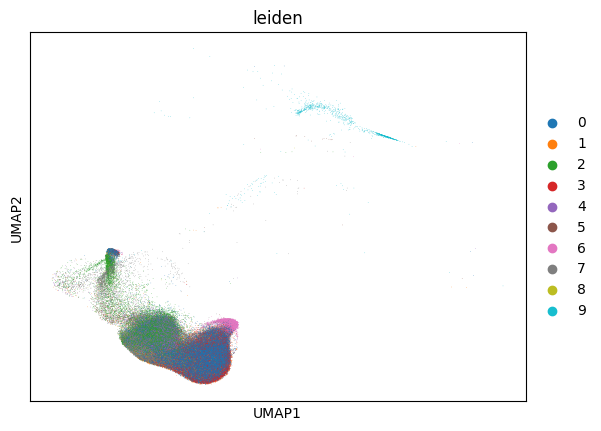

In [18]:
sc.pl.umap(adata_NK, color="leiden")

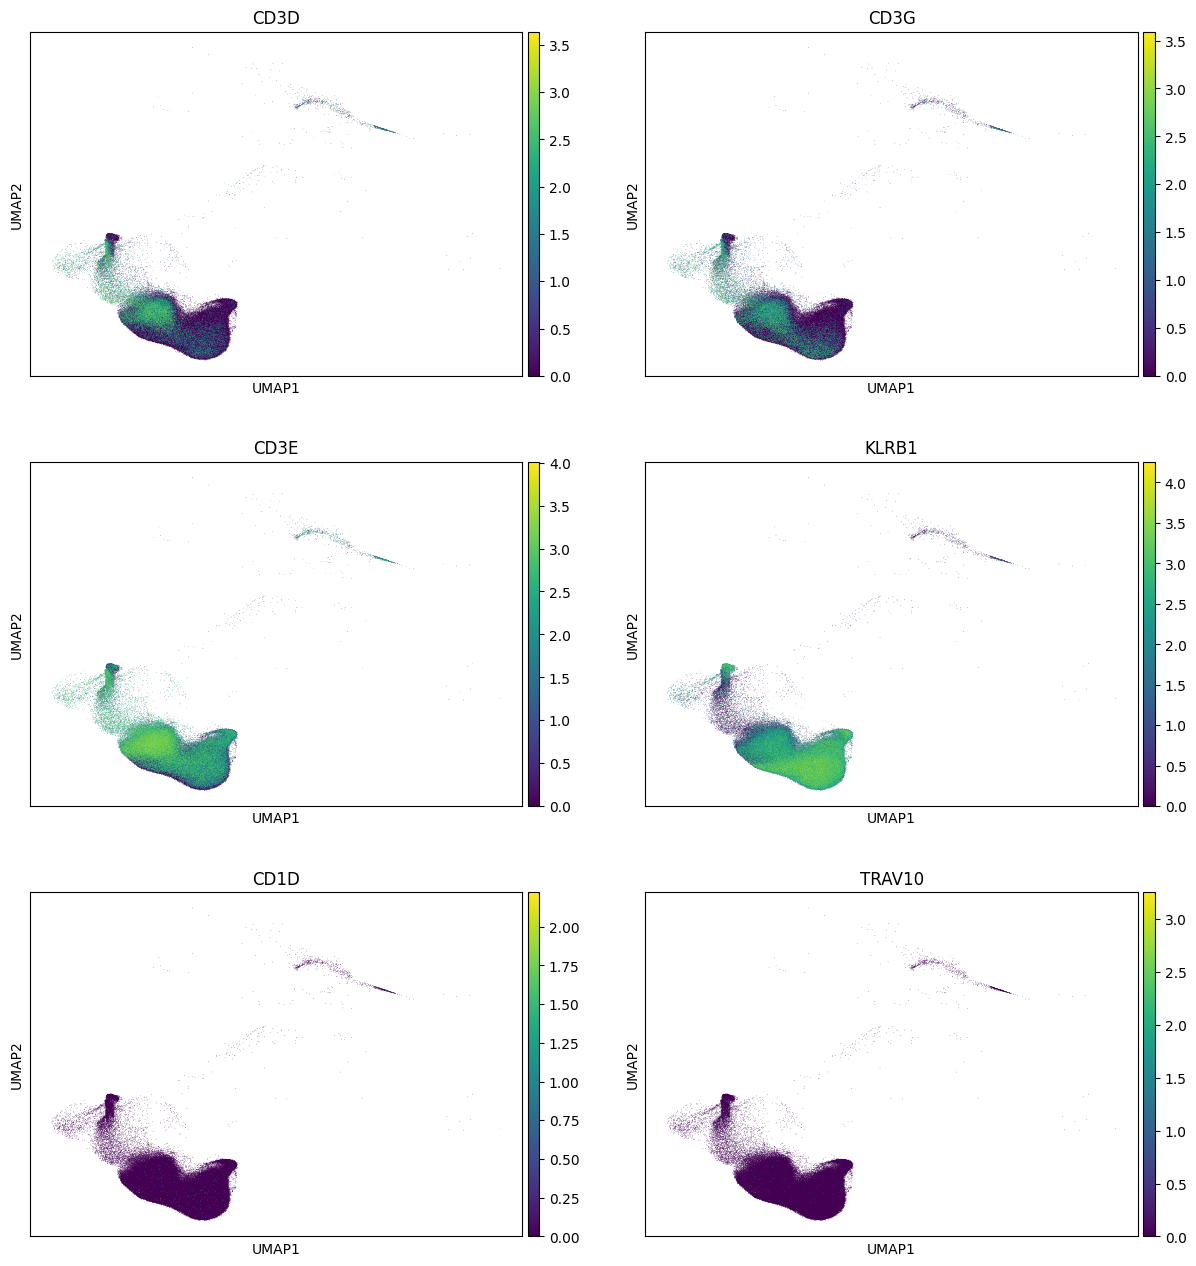

In [19]:
NKT_markers = ["CD3D", "CD3G", "CD3E", "KLRB1", "CD1D", "TRAV10"]

sc.pl.umap(adata_NK, color=NKT_markers, ncols=2)

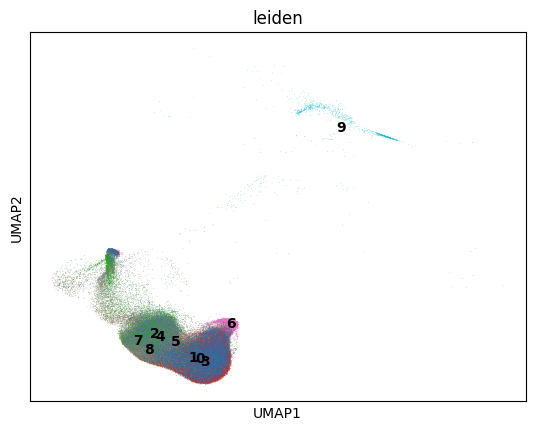

In [20]:
sc.pl.umap(adata_NK, color="leiden", legend_loc="on data")

In [21]:
assert adata_NK.var.index.equals(adata_NK_raw.var.index)
adata_NK_raw.obs["leiden"] = adata_NK.obs["leiden"]

/tmp/ipykernel_145868/3229624995.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_NK_raw.obs["leiden"] = adata_NK.obs["leiden"]


In [22]:
%autoreload
from datasim.de_testing.testing import calc_pseudobulk_stats
from datasim.de_testing.selection import (
    select_and_combine_de_results,
    sort_and_filter_de_genes_ova,
    sort_and_filter_de_genes_ava,
)

In [23]:
de_res_ova, de_res_ava = calc_pseudobulk_stats(
    adata_NK_raw,
    cluster_label="leiden",
    sample_label="sample_uuid"
)

R[write to console]: data.table 1.15.4 using 8 threads (see ?getDTthreads).  
R[write to console]: Latest news: r-datatable.com

Calculating AVA AUROC scores: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [06:14<00:00,  8.32s/it]


In [24]:
res = select_and_combine_de_results(
    sort_and_filter_de_genes_ova(
        de_res_ova,
        logfc_threshold=0.,
        aucroc_threshold=0.0
    ),
    sort_and_filter_de_genes_ava(
        de_res_ava,
        logfc_threshold=0.,
        aucroc_threshold=0.0
    ),
    overlap_threshold=0.3,
    n_genes_ova=None,
    n_genes_ava=None
)

In [25]:
from IPython.display import display

In [26]:
for cluster in np.unique(adata_NK_raw.obs.leiden):
    df = res[cluster]
    df = df.head(15)
    print(cluster)
    display(
        df.style
        .format("{:.2f}", subset=["logFC", "auroc"])
        .format("{:.3f}", subset=["adj.P.Val"])
    )
    print()

0


,logFC,adj.P.Val,auroc,reference
ID,,,,
PTGDS,1.62,0.000,0.51,['all']
CCL4,1.55,0.000,0.54,['all']
CCL3,1.51,0.000,0.53,['all']
AREG,1.39,0.000,0.65,['all']
RBM38,1.32,0.000,0.74,['all']
RGS2,1.31,0.000,0.62,['all']
CXCR4,1.27,0.000,0.73,['all']
TAMALIN,1.23,0.000,0.62,['all']
RGS1,1.21,0.000,0.62,['all']



1


,logFC,adj.P.Val,auroc,reference
PTGDS,1.41,0.000,0.54,['all']
SPON2,1.33,0.000,0.59,['all']
CX3CR1,1.19,0.000,0.66,['all']
CLIC3,1.17,0.000,0.62,['all']
FCER1G,1.13,0.000,0.64,['all']
FGFBP2,1.11,0.000,0.55,['all']
AKR1C3,1.11,0.000,0.57,['all']
CCL4,1.05,0.000,0.54,['all']
LAIR2,1.04,0.000,0.55,['all']
ALOX5AP,1.00,0.000,0.59,['all']



2


...

,logFC,adj.P.Val,auroc,reference
ID,,,,
SYNE2,1.74,0.000,0.70,['all']
BCL11B,1.34,0.000,0.62,['all']
CD3G,1.33,0.000,0.61,['all']
IKZF3,1.31,0.000,0.63,['all']
ZEB2,1.26,0.000,0.60,['all']
RORA,1.15,0.000,0.60,['all']
THEMIS,1.13,0.000,0.58,['all']
CD3D,1.09,0.000,0.59,['all']
SYNE1,1.08,0.000,0.66,['all']



8


,logFC,adj.P.Val,auroc,reference
ID,,,,
RBM38,1.83,0.000,0.72,['all']
PER1,1.67,0.000,0.63,['all']
TSPYL2,1.55,0.000,0.62,['all']
CXCR4,1.54,0.001,0.68,['all']
RGS1,1.53,0.000,0.59,['all']
IFNGR1,1.44,0.000,0.60,['all']
SLA2,1.39,0.000,0.65,['all']
ANKRD9,1.39,0.000,0.56,['all']
PPP1R16B,1.37,0.000,0.65,['all']



9


,logFC,adj.P.Val,auroc,reference
ID,,,,
S100A9,3.95,0.000,0.92,['all']
S100A8,3.83,0.000,0.89,['all']
HBB,3.70,0.000,0.64,['all']
LYZ,3.60,0.000,0.91,['all']
VCAN,3.54,0.000,0.81,['all']
IL1B,3.34,0.000,0.72,['all']
AIF1,3.03,0.000,0.74,['all']
FCN1,2.99,0.000,0.73,['all']
TEX14,2.96,0.000,0.68,['all']


In [27]:
for cluster in np.unique(adata_NK_raw.obs.leiden):
    df = res[cluster]
    df.index.name = "ID"
    print(cluster)
    display(
        df
        .reset_index()
        .query(f'`ID` in {NKT_markers}')
        .style
        .format("{:.2f}", subset=["logFC", "auroc"])
        .format("{:.3f}", subset=["adj.P.Val"])
    )
    print()


0


,ID,logFC,adj.P.Val,auroc,reference
54,KLRB1,0.83,0.000,0.63,['all']



1


,ID,logFC,adj.P.Val,auroc,reference
29,KLRB1,0.69,0.000,0.55,['all']
204,CD3E,0.40,0.000,0.56,['3']
661,CD3D,0.24,0.013,0.53,['3']



2


...

,ID,logFC,adj.P.Val,auroc,reference
2,CD3G,1.33,0.000,0.61,['all']
7,CD3D,1.09,0.000,0.59,['all']
1573,CD3E,0.22,0.003,0.49,['all']



8


,ID,logFC,adj.P.Val,auroc,reference



9


,ID,logFC,adj.P.Val,auroc,reference
142,CD3D,1.70,0.000,0.64,['all']
290,CD3G,1.35,0.000,0.60,['all']
1844,CD1D,0.52,0.000,0.52,['all']


In [28]:
adata_NK.obs["author_cell_type_fine"] = adata_NK.obs["author_cell_type"].astype(str).copy()

adata_NK.obs.loc[
    adata_NK.obs.leiden.isin(["2", "4"]), 
    "author_cell_type_fine"
] = "NKT"

In [29]:
adata_NK.obs["author_cell_type_fine"] = adata_NK.obs["author_cell_type_fine"].astype("category")
adata_NK_raw.obs["author_cell_type_fine"] = adata_NK.obs["author_cell_type_fine"].astype("category")

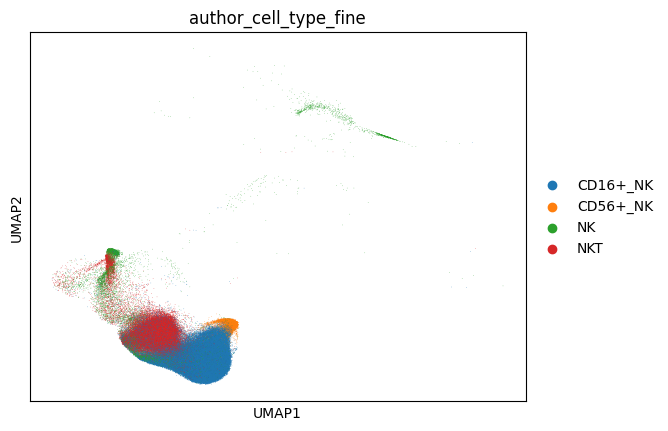

In [30]:
sc.pl.umap(adata_NK, color=["author_cell_type_fine"])

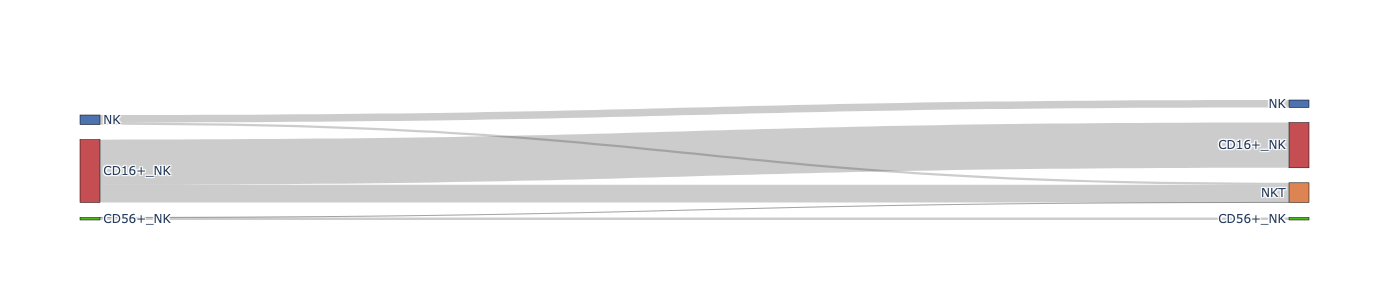

In [50]:
import plotly.graph_objects as go

from itertools import product


clusters_before = adata_NK.obs.author_cell_type.unique().tolist()
clusters_after = adata_NK.obs.author_cell_type_fine.unique().tolist()
change = {}

for ct in adata_NK.obs["author_cell_type"].unique():
    change[ct] = adata_NK[adata_NK.obs["author_cell_type"] == ct].obs["author_cell_type_fine"].value_counts().to_dict()

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = clusters_before + clusters_after,
      color = ["#4C72B0", "#C44E52", "#4CBB17", "#4C72B0", "#DD8452", "#C44E52", "#4CBB17"]
    ),
    link = dict(
      source = np.repeat(np.arange(len(clusters_before)), len(clusters_after)),
      target = np.tile(np.arange(len(clusters_before), len(clusters_after) + len(clusters_before)), len(clusters_before)),
      value = [change[ct1].get(ct2, 0) for ct1, ct2 in product(clusters_before, clusters_after)]
  ))])

fig.update_layout(
    width=500, height=300
)
fig.write_image("cluster_change_REF_NKT.svg")

fig.show()

In [32]:
# percentage of cells from the NK cluster which got assigned to the new NKT cluster
change["NK"]["NKT"] / sum(change["NK"].values())

0.21188775071016613

In [33]:
# percentage of cells from the CD16+_NK cluster which got assigned to the new NKT cluster
change["CD16+_NK"]["NKT"] / sum(change["CD16+_NK"].values())

0.2803138702977152

In [34]:
adata_NK.obs["author_cell_type_fine"].value_counts(normalize=True)

author_cell_type_fine
CD16+_NK    0.602869
NKT         0.262024
NK          0.101143
CD56+_NK    0.033965
Name: proportion, dtype: float64

In [35]:
adata_NK.obs["author_cell_type"].value_counts(normalize=True)

author_cell_type
CD16+_NK    0.837683
NK          0.128336
CD56+_NK    0.033981
Name: proportion, dtype: float64

In [36]:
de_res_ova, de_res_ava = calc_pseudobulk_stats(
    adata_NK_raw,
    cluster_label="author_cell_type_fine",
    sample_label="sample_uuid"
)

Calculating AVA AUROC scores: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:52<00:00, 18.72s/it]


In [37]:
res_combined = select_and_combine_de_results(
    sort_and_filter_de_genes_ova(
        de_res_ova,
        logfc_threshold=0.
    ),
    sort_and_filter_de_genes_ava(
        de_res_ava,
        logfc_threshold=0.
    ),
    overlap_threshold=0.3
)

In [38]:
res_combined["NKT"]

,logFC,adj.P.Val,auroc,reference
ID,,,,
LAG3,1.753736,3.618437e-283,0.674175,[all]
PTMS,1.688811,4.448268e-277,0.687343,[all]
GZMH,1.436434,2.096556e-101,0.769752,[all]
CD3E,1.315780,2.475537e-135,0.750018,[all]
IL32,1.181822,2.037078e-126,0.748248,[all]
IFNG,1.104571,9.873188e-63,0.627335,[all]
S100A6,1.083846,6.520637e-149,0.731372,[all]
KLRC2,1.000281,6.593621e-59,0.767288,[all]
CCL5,0.967659,1.093174e-107,0.758635,[all]


In [39]:
adata_NK.write_h5ad("NKT_subset.h5ad")

## Update cell type annotations

In [1]:
import scanpy as sc

In [2]:
adata_NK = sc.read_h5ad("NKT_subset.h5ad")

In [3]:
adata_preprocessed = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/preprocessed/"
    "ced320a1-29f3-47c1-a735-513c7084d508_CAP.h5ad",
)

In [4]:
nkt_cells = adata_NK.obs[adata_NK.obs.author_cell_type_fine == "NKT"].index.to_numpy()

In [5]:
adata_preprocessed.obs["cell_type_author"] = adata_preprocessed.obs["cell_type_author"].astype(str)
adata_preprocessed.obs.loc[nkt_cells, "cell_type_author"] = "NKT"
adata_preprocessed.obs["cell_type_author"] = adata_preprocessed.obs["cell_type_author"].astype("category")

In [6]:
adata_preprocessed.obs.cell_type_author.value_counts()

cell_type_author
CD14+_Monocyte     202124
CD4+_T_naive       157616
CD4+_T_cm          110004
CD16+_NK           109144
CD8+_T_naive        89029
T_unknown           54800
CD8+_T_unknown      53658
NKT                 47437
CD16+_Monocyte      46628
CD8+_T_GZMBhi       46528
CD4+_T              40100
naive_B             36778
CD8+_T_GZMKhi       28138
Myeloid             26020
CD4+_T_em           25012
MAIT                23001
memory_B_IGHMlo     19146
gdT_GZMKhi          18835
NK                  18311
Treg                15497
Platelet            14799
CD4+_T_cyt          13594
cDC2                13207
memory_B_IGHMhi     12222
gdT_GZMBhi          11860
B_unknown            9144
CD56+_NK             6149
atypical_B           4850
pDC                  3796
memory_B             3746
Plasma_Cell          1672
DC_SIGLEC6hi          894
ILC                   707
cDC1                  554
dnT                   489
CD34_HSPC             135
Name: count, dtype: int64

In [7]:
adata_preprocessed.write_h5ad(
    "/vol/data/dataset-similarity/preprocessed/ced320a1-29f3-47c1-a735-513c7084d508_CAP_NKT_CD3E.h5ad",
    compression="gzip"
)